# Predicting Titanic Survival using Machine Learning
This notebook explores the fumose **Titanic dataset** to build a Machine Learning model that predict passenger survival based on features like age, gender, ticket clss and more.

## Dataset:
The dataset contains information about passengers aboard the RMS Titanic, including:
- **PassengerId**: Unique ID for each passenger
- **Pclass**: Ticket class (1st, 2nd, 3rd)
- **Name**: Passenger name
- **Sex**: Gender
- **Age**: Age in years
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Ticket**: Ticket number
- **Fare**: Ticket fare
- **Cabin**: Cabin number
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
- **Survived**: Target variable (0 = Did not survive, 1 = Survived)

## We're going to take the folowing approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling

---

# Preparing the tools

In [74]:
# Import all the tools that we need

# Regular EDA (Exploratory Data Analysis) and plotting libraries
import warnings

warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split, cross-validation score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

---

# Load The Data

In [75]:
train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")
gender_submission = pd.read_csv("titanic/gender_submission.csv")

---

# Data Exploration (Data Exploratory Analysis or EDA)
* Problem definition
* Data
* Evaluation
* Features

The goal here is to find out more about the data and become a subject matter export on the dataset you're working with.

In [76]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [77]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [78]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [80]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [81]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [82]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
train.shape

(891, 12)

In [84]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

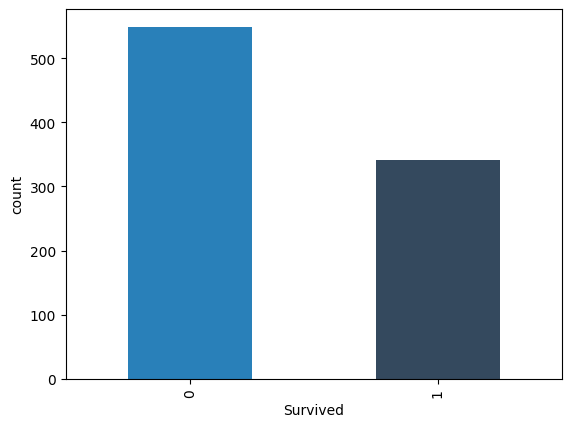

In [85]:
train["Survived"].value_counts().plot(kind = "bar", color = ['#2980b9', '#34495e'], ylabel = "count");

In [86]:
train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

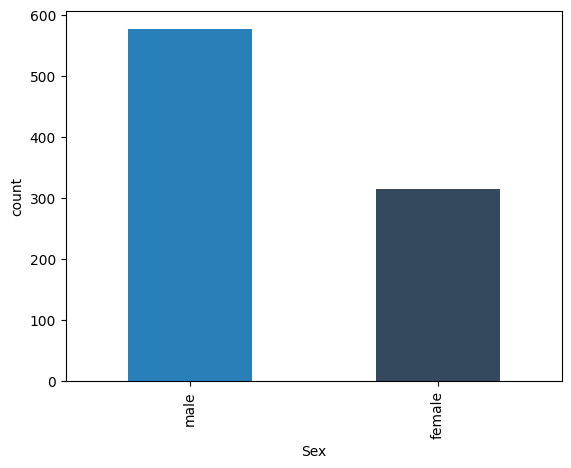

In [87]:
train["Sex"].value_counts().plot(kind = "bar", color = ['#2980b9', '#34495e'], ylabel = "count");

In [88]:
train["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

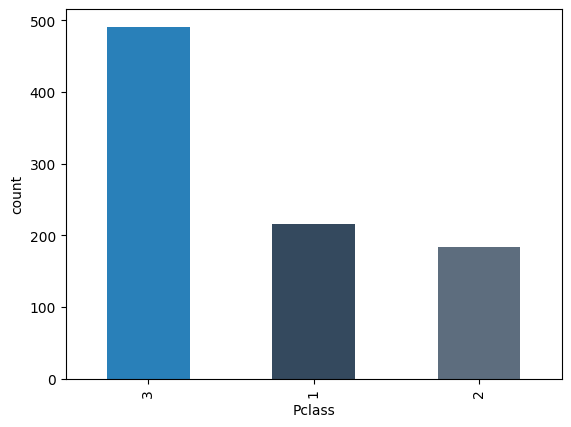

In [89]:
train["Pclass"].value_counts().plot(kind = "bar", color = ['#2980b9', '#34495e', '#5d6d7e'], ylabel = "count");

In [90]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

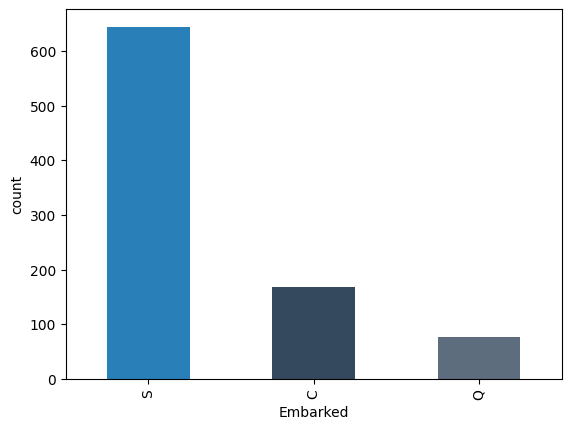

In [91]:
train["Embarked"].value_counts().plot(kind = "bar", color = ['#2980b9', '#34495e', '#5d6d7e'], ylabel = "count");

In [92]:
train["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

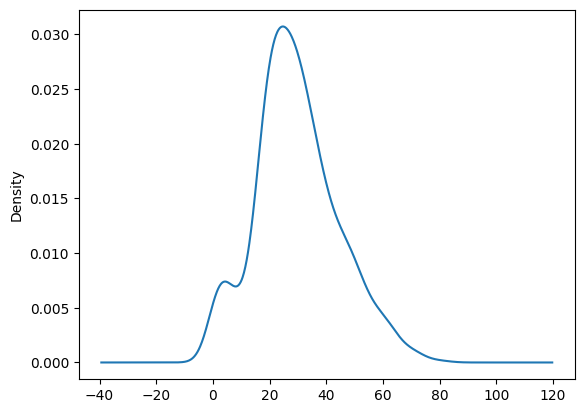

In [93]:
train["Age"].plot(kind = "kde");

In [94]:
train["Fare"]

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

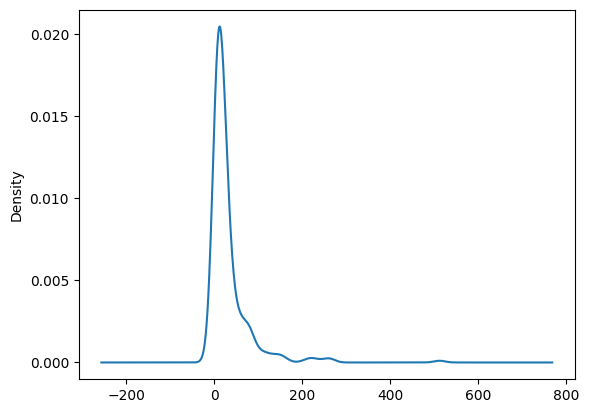

In [95]:
train["Fare"].plot(kind = "kde");

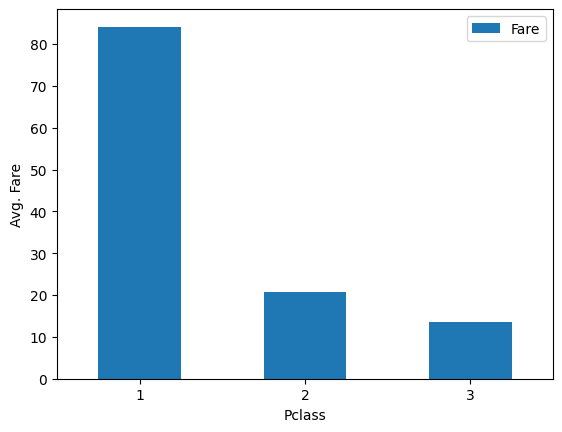

In [96]:
# Pivot table showing average fare by passenger class, visualized as a bar plot
class_fare = train.pivot_table(index = "Pclass", values = "Fare")
class_fare.plot(kind = "bar")
plt.xlabel("Pclass")
plt.ylabel("Avg. Fare")
plt.xticks(rotation = 0);

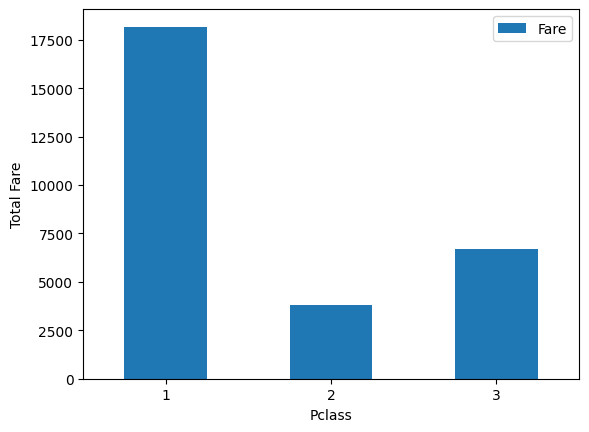

In [97]:
# Pivot table showing total fare by passenger class, visualized as a bar plot
class_fare = train.pivot_table(index = "Pclass", values = "Fare", aggfunc = np.sum)
class_fare.plot(kind = "bar")
plt.xlabel("Pclass")
plt.ylabel("Total Fare")
plt.xticks(rotation = 0);

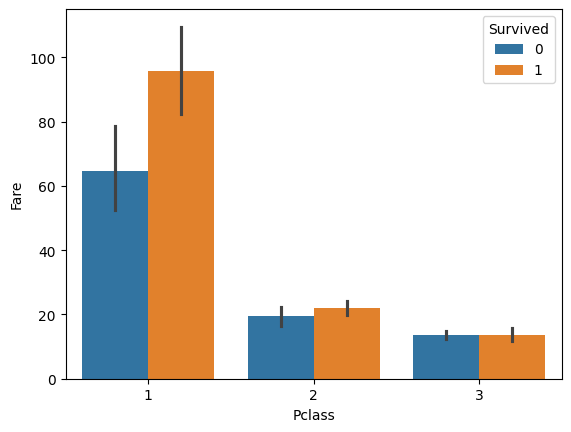

In [98]:
# Bar plot comparing fare by passenger class, split by survival status
sns.barplot(data = train, x = "Pclass", y = "Fare", hue = "Survived");

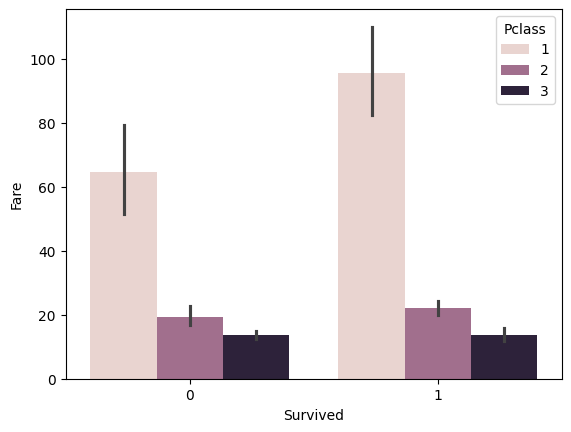

In [99]:
# Bar plot comparing fare by survival status, broken down by passenger class
sns.barplot(data = train, x = "Survived", y = "Fare", hue = "Pclass");

---

# Data Preprocessing

In [100]:
# Store original train length for later reference
train_len = len(train)

# Combine train and test datasets vertically (row-wise) for joint preprocessing
df = pd.concat([train, test], axis = 0)

# Reset index to avoid duplicate index values after concatenation
df = df.reset_index(drop = True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [101]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [102]:
df.shape

(1309, 12)

In [103]:
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [104]:
# Drop the "Cabin" column from the combined dataframe (too many missing values)
df = df.drop(columns = ["Cabin"])

In [105]:
df["Age"].mean()

np.float64(29.881137667304014)

In [106]:
# Fill missing values using mean of the numerical columns
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

In [107]:
df["Embarked"].mode()[0]

'S'

In [108]:
# Fill missing values using mode of the categorical column
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Log transformation for uniform data distribution

In [109]:
df["Fare"]

0         7.2500
1        71.2833
2         7.9250
3        53.1000
4         8.0500
          ...   
1304      8.0500
1305    108.9000
1306      7.2500
1307      8.0500
1308     22.3583
Name: Fare, Length: 1309, dtype: float64

<Axes: ylabel='Density'>

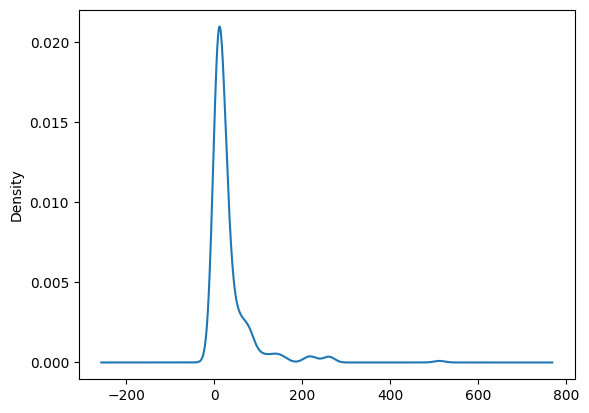

In [110]:
df["Fare"].plot(kind = "kde")

In [111]:
# Apply log transformation to Fare to reduce skewness (add 1 to avoid log(0))
df['Fare'] = np.log(df['Fare']+1)
df["Fare"]

0       2.110213
1       4.280593
2       2.188856
3       3.990834
4       2.202765
          ...   
1304    2.202765
1305    4.699571
1306    2.110213
1307    2.202765
1308    3.150952
Name: Fare, Length: 1309, dtype: float64

<Axes: ylabel='Density'>

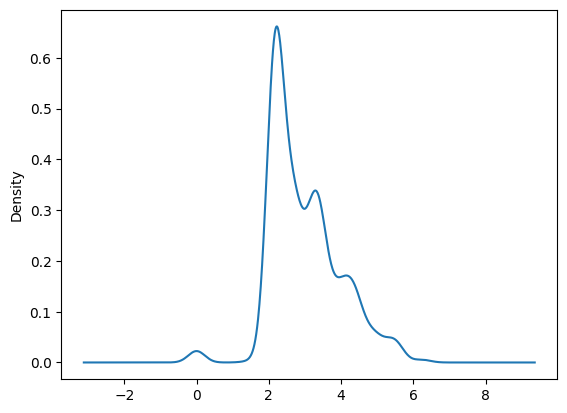

In [112]:
df["Fare"].plot(kind = "kde")

In [113]:
# Drop Unnecessary columns
df = df.drop(columns = ["Name", "Ticket"])
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,male,22.0,1,0,2.110213,S
1,2,1.0,1,female,38.0,1,0,4.280593,C
2,3,1.0,3,female,26.0,0,0,2.188856,S
3,4,1.0,1,female,35.0,1,0,3.990834,S
4,5,0.0,3,male,35.0,0,0,2.202765,S


In [114]:
df.isna().sum()

PassengerId      0
Survived       418
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64

# Label Encoding

In [115]:
#  Encode categorical columns (Sex, Embarked) using LabelEncoder
ls = LabelEncoder()

for col in cols:
    df[col] = ls.fit_transform(df[col])
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,1,22.0,1,0,2.110213,2
1,2,1.0,1,0,38.0,1,0,4.280593,0
2,3,1.0,3,0,26.0,0,0,2.188856,2
3,4,1.0,1,0,35.0,1,0,3.990834,2
4,5,0.0,3,1,35.0,0,0,2.202765,2


# Correlation Matrix

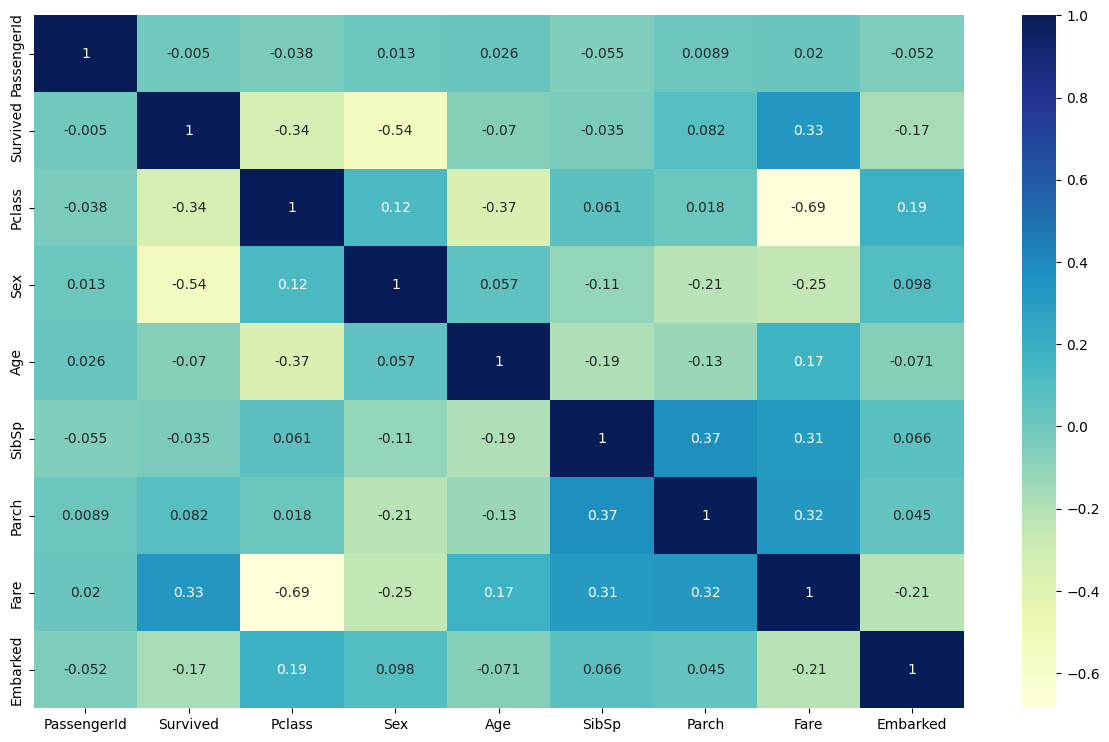

In [116]:
# Correlation heatmap to visualize relationships between all numerical features
corr = df.corr()
fig, ax = plt.subplots(figsize = (15, 9))
ax = sns.heatmap(
    corr,
    annot = True,
    cmap = "YlGnBu"
)

# Train - Test - Split

In [117]:
# Split the combined dataset back into train and test sets using the original train length
train = df.iloc[:train_len, :]
test = df.iloc[train_len:, :]

In [118]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,1,22.0,1,0,2.110213,2
1,2,1.0,1,0,38.0,1,0,4.280593,0
2,3,1.0,3,0,26.0,0,0,2.188856,2
3,4,1.0,1,0,35.0,1,0,3.990834,2
4,5,0.0,3,1,35.0,0,0,2.202765,2


In [119]:
test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
891,892,NaN,3,1,34.5,0,0,2.178064,1
892,893,NaN,3,0,47.0,1,0,2.079442,2
893,894,NaN,2,1,62.0,0,0,2.369075,1
894,895,NaN,3,1,27.0,0,0,2.268252,2
895,896,NaN,3,0,22.0,1,1,2.586824,2


In [120]:
train.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [121]:
test.isna().sum()

PassengerId      0
Survived       418
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64

In [122]:
# Prepare features and target for model training
X = train.drop(columns = ["PassengerId", "Survived"])
y = train["Survived"]

In [123]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,2.110213,2
1,1,0,38.0,1,0,4.280593,0
2,3,0,26.0,0,0,2.188856,2
3,1,0,35.0,1,0,3.990834,2
4,3,1,35.0,0,0,2.202765,2


In [124]:
y

0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
886    0.0
887    1.0
888    0.0
889    1.0
890    0.0
Name: Survived, Length: 891, dtype: float64

# Model Training

In [125]:
# Define function to train and evaluate any model with train-test split and cross-validation
def classify(model):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
    model.fit(X_train, y_train)
    print("Accuracy: ", model.score(X_test, y_test))

    score = cross_val_score(model, X, y, cv = 5)
    print("CV Score: ", np.mean(score))

In [126]:
# Logistic Regression
model = LogisticRegression()
classify(model)

Accuracy:  0.8071748878923767
CV Score:  0.7833971502102819


In [127]:
# Decision Tree Classifier
model = DecisionTreeClassifier()
classify(model)

Accuracy:  0.7399103139013453
CV Score:  0.7688343481262947


In [128]:
# Random Forest Classifier
model = RandomForestClassifier()
classify(model)

Accuracy:  0.7937219730941704
CV Score:  0.8137153976523759


In [129]:
# Extra Trees Classifier
model = ExtraTreesClassifier()
classify(model)

Accuracy:  0.7937219730941704
CV Score:  0.7957755319816708


In [130]:
# XGBoost Classifier
model = XGBClassifier()
classify(model)

Accuracy:  0.7802690582959642
CV Score:  0.8159751428033394


In [131]:
# LGBM Classifier
model = LGBMClassifier()
classify(model)

[LightGBM] [Info] Number of positive: 253, number of negative: 415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 191
[LightGBM] [Info] Number of data points in the train set: 668, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.378743 -> initscore=-0.494889
[LightGBM] [Info] Start training from score -0.494889
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [132]:
# CatBoost Classifier
model = CatBoostClassifier()
classify(model)

Learning rate set to 0.008672
0:	learn: 0.6869162	total: 3.2ms	remaining: 3.19s
1:	learn: 0.6815250	total: 4.43ms	remaining: 2.21s
2:	learn: 0.6759001	total: 6.07ms	remaining: 2.02s
3:	learn: 0.6702154	total: 7.68ms	remaining: 1.91s
4:	learn: 0.6671731	total: 8.27ms	remaining: 1.65s
5:	learn: 0.6620922	total: 9.31ms	remaining: 1.54s
6:	learn: 0.6563299	total: 10.3ms	remaining: 1.46s
7:	learn: 0.6531383	total: 11.2ms	remaining: 1.39s
8:	learn: 0.6475000	total: 12.2ms	remaining: 1.34s
9:	learn: 0.6421420	total: 13.2ms	remaining: 1.3s
10:	learn: 0.6370829	total: 14.1ms	remaining: 1.27s
11:	learn: 0.6323947	total: 15.2ms	remaining: 1.25s
12:	learn: 0.6280403	total: 16.2ms	remaining: 1.23s
13:	learn: 0.6238733	total: 17.1ms	remaining: 1.2s
14:	learn: 0.6187057	total: 18.3ms	remaining: 1.2s
15:	learn: 0.6140627	total: 19.3ms	remaining: 1.19s
16:	learn: 0.6092221	total: 21.4ms	remaining: 1.24s
17:	learn: 0.6057773	total: 22.4ms	remaining: 1.22s
18:	learn: 0.6012526	total: 23.5ms	remaining: 1.

---

# Complete Model Training with Full data
After evaluating multiple models, LightGBM performed best

In [145]:
# After evaluating multiple models, LightGBM performed best
# Train final model on full training data
model = LGBMClassifier()
model.fit(X, y)

[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 222
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [134]:
test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
891,892,NaN,3,1,34.5,0,0,2.178064,1
892,893,NaN,3,0,47.0,1,0,2.079442,2
893,894,NaN,2,1,62.0,0,0,2.369075,1
894,895,NaN,3,1,27.0,0,0,2.268252,2
895,896,NaN,3,0,22.0,1,1,2.586824,2


In [135]:
# Prepare test features by dropping PassengerId and Survived
X_test = test.drop(columns = ["PassengerId", "Survived"])

In [136]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
891,3,1,34.5,0,0,2.178064,1
892,3,0,47.0,1,0,2.079442,2
893,2,1,62.0,0,0,2.369075,1
894,3,1,27.0,0,0,2.268252,2
895,3,0,22.0,1,1,2.586824,2


In [137]:
# Make prediction
pred = model.predict(X_test)
pred

array([0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 0.

In [144]:
print(y.shape)
print(pred.shape)

(891,)
(418,)


# Test Submission

In [ ]:
sub = pd.read_csv("titanic/gender_submission.csv")

In [ ]:
sub

In [ ]:
sub.info()

In [ ]:
# Add predictions to submission dataframe and convert to integer format
sub["Survived"] = pred
sub["Survived"] = sub["Survived"].astype("int")

In [ ]:
sub.info()

In [ ]:
sub.head()

In [ ]:
# Save predictions to CSV file for Kaggle submission
sub.to_csv('submission.csv', index=False)